In [7]:
!pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.5-py3-none-any.whl.metadata (4.0 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------

In [9]:
!pip install tensorflow_hub

  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ ----------------------

In [26]:
import os
os.environ["TFHUB_OFFLINE"] = "1"
os.environ['TFHUB_CACHE_DIR'] = './tfhub_modules' # Point to your cache
os.environ['TFHUB_DOWNLOAD_PROGRESS'] = '1'       # See if it's actually downloading
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [3]:
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import scipy
from PIL import Image
from matplotlib.pyplot import imshow

c:\Anaconda\envs\densehybrid\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [4]:
#metric for measuring quality performance (ignore for testing on a single image)
def srcc(y_true, y_pred):
     return ( tf.py_function(spearmanr, [tf.cast(y_pred, tf.float32),
                       tf.cast(y_true, tf.float32)], Tout = tf.float32) )

In [5]:
IMG_SIZE = 448
CHANNELS = 3 

In [ ]:
# #preprocessing for input
# def test_img(filename, model):
#     image_string = tf.io.read_file(filename)
#     image_decoded = tf.image.decode_jpeg(image_string, channels=CHANNELS)
#     image_resized = tf.image.resize(image_decoded, [IMG_SIZE, IMG_SIZE])
#     image_normalized = image_resized / 255.0
#     pred = model.predict(np.array([image_normalized,]))
#     return pred

# Preprocessing for input for roipool
def test_img(filename, model):
    image_string = tf.io.read_file(filename)
    image_decoded = tf.image.decode_jpeg(image_string, channels=CHANNELS)
    image_resized = tf.image.resize(image_decoded, [IMG_SIZE, IMG_SIZE])
    image_normalized = image_resized / 255.0
    
    # Create dummy ROI that covers the entire image
    # ROI format: [x, y, width, height]
    # For full image coverage on 448x448 image
    roi = np.array([[0, 0, IMG_SIZE, IMG_SIZE]], dtype=np.float32)
    
    pred = model.predict({
        'input_layer': np.array([image_normalized]),
        'input_rois': roi
    })
    return pred

In [21]:
IMG_SIZE = 448
CHANNELS = 3 

In [22]:
# For resnet50
def build_model():
    IMG_SIZE = 448
    CHANNELS = 3

    # Base feature extractor (same as training)
    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # Input
    input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    # Backbone
    x = base_model(input_layer, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='hidden_layer1')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Head 1 → Quality score (output_2)
    x1 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2')(x)
    x1 = tf.keras.layers.Dropout(0.2)(x1)
    output_2 = tf.keras.layers.Dense(1, name='output_2')(x1)

    # Head 2 → Distortion distribution (output_1)
    x2 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3')(x)
    x2 = tf.keras.layers.Dropout(0.2)(x2)
    output_1 = tf.keras.layers.Dense(7, name='output_1')(x2)

    model = tf.keras.models.Model(inputs=input_layer,
                                  outputs=[output_1, output_2])

    return model

# For roipool
# from tensorflow.keras.layers import Layer
# from tensorflow.keras import backend as K

# class RoiPoolingConv(Layer):
#     def __init__(self, pool_size, num_rois, **kwargs):
#         self.pool_size = pool_size
#         self.num_rois = num_rois
#         super(RoiPoolingConv, self).__init__(**kwargs)

#     def build(self, input_shape):
#         self.nb_channels = input_shape[0][3]

#     def compute_output_shape(self, input_shape):
#         return None, self.num_rois, self.pool_size, self.pool_size, self.nb_channels

#     def call(self, x, mask=None):
#         assert(len(x) == 2)
        
#         img = x[0]
#         rois = x[1]
        
#         x = rois[0, 0]
#         y = rois[0, 1]
#         w = rois[0, 2]
#         h = rois[0, 3]
        
#         x = K.cast(x, 'int32')
#         y = K.cast(y, 'int32')
#         w = K.cast(w, 'int32')
#         h = K.cast(h, 'int32')
        
#         rs = tf.image.resize(img[:, y:y+h, x:x+w, :], (self.pool_size, self.pool_size))
        
#         batch_size = K.shape(img)[0]
#         final_output = K.reshape(rs, (batch_size, self.num_rois, self.pool_size, self.pool_size, self.nb_channels))
#         return final_output

#     def get_config(self):
#         config = {'pool_size': self.pool_size,
#                   'num_rois': self.num_rois}
#         base_config = super(RoiPoolingConv, self).get_config()
#         return dict(list(base_config.items()) + list(config.items()))

# def build_model():
#     IMG_SIZE = 448
#     CHANNELS = 3
    
#     # Base feature extractor
#     base_model = tf.keras.applications.ResNet50V2(
#         input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
#         include_top=False,
#         weights='imagenet'
#     )
#     base_model.trainable = False
    
#     # Inputs
#     input_rois = tf.keras.layers.Input(shape=(4,), name='input_rois')
#     input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name='input_layer')
    
#     # Base model extracts features
#     base_layers = base_model(input_layer, training=False)
    
#     # ROI pooling to extract 2x2 region
#     out_roi_pool = RoiPoolingConv(2, 1)([base_layers, input_rois])
    
#     # Flatten and pass through dense layers
#     x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten(name='flatten'))(out_roi_pool)
#     x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(512, activation='relu', name='fc1'))(x)
#     x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x)
    
#     # Head 1 → Quality score (output_1)
#     x1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2'))(x)
#     x1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x1)
#     output_1 = tf.keras.layers.Dense(1, name='output_1')(x1)
    
#     # Head 2 → Distortion distribution (output_2)
#     x2 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3'))(x)
#     x2 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dropout(0.2))(x2)
#     output_2 = tf.keras.layers.Dense(7, name='output_2')(x2)
    
#     model = tf.keras.models.Model(inputs=[input_layer, input_rois], 
#                                   outputs=[output_1, output_2])
    
#     return model

In [23]:
# For mobilenet
def build_model_mobilenet():
    IMG_SIZE = 448
    CHANNELS = 3

    # Base feature extractor (MobileNetV2)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # Input
    input_layer = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))

    # Backbone
    x = base_model(input_layer, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='hidden_layer1')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Head 1 → Quality score (output_2)
    x1 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer2')(x)
    x1 = tf.keras.layers.Dropout(0.2)(x1)
    output_2 = tf.keras.layers.Dense(1, name='output_2')(x1)

    # Head 2 → Distortion distribution (output_1)
    x2 = tf.keras.layers.Dense(32, activation='relu', name='hidden_layer3')(x)
    x2 = tf.keras.layers.Dropout(0.2)(x2)
    output_1 = tf.keras.layers.Dense(7, name='output_1')(x2)

    model = tf.keras.models.Model(inputs=input_layer,
                                  outputs=[output_1, output_2])

    return model

In [ ]:
#change the path to the test model
# This ignores the 'srcc' metric entirely during loading, which is much faster
# test_model = tf.keras.models.load_model(
#     'test_models/resnet50.h5', 
#     custom_objects={'KerasLayer': hub.KerasLayer},
#     compile=False
# )
# test_model = tf.keras.models.load_model('test_models/resnet50.h5', custom_objects={'KerasLayer':hub.KerasLayer,'srcc':srcc})

# roipool
# test_model = build_model()
# test_model.load_weights('test_models/resnet50_roipool.h5')

# For ResNet50 (use test_img_simple)
# test_model = build_model()
# test_model.load_weights('test_models/resnet50.h5')
# test_preprocessing = test_img_simple

# For MobileNet (use test_img_simple)
test_model = build_model_mobilenet()
test_model.load_weights('test_models/mobilenet.h5')
test_preprocessing = test_img

C:\Users\YASHVI KHATRI\AppData\Local\Temp\ipykernel_8212\1341181866.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [ ]:
# def feedback(img, model, test_img):
#     im = Image.open(img)
#     imshow(np.asarray(im))
#     pred = test_img(img, model)
#     # roipool
#     qual = float(pred[0][0][0]) 
#     dist = pred[1][0][0]

#     # resnet50
#     # qual = pred[1].item() 
#     # dist = pred[0][0]
#     print('Predicted global quality: ', qual)
#     D = ['Blurry','Shaky','Bright','Dark','Grainy','None','Other']
#     idx = np.argmax(dist)
#     print('Most prominent distortion: ',D[idx])
#     idx3 = dist.argsort()[-3:][::-1]
#     print('Max 3 prominent distortions are: ', [D[i] for i in idx3])        
#     print('All distortions: ')
#     for i in range(7):
#         print(D[i],': ',dist[i])

# Mobilenet
def feedback(img, model, test_preprocessing):
    im = Image.open(img)
    imshow(np.asarray(im))
    pred = test_preprocessing(img, model)
    
    # For simple models (MobileNet, ResNet50)
    qual = float(pred[1][0][0])  # Quality score from output_2
    dist = pred[0][0]  # Distortion distribution from output_1
    
    print('Predicted global quality: ', qual)
    D = ['Blurry','Shaky','Bright','Dark','Grainy','None','Other']
    idx = np.argmax(dist)
    print('Most prominent distortion: ',D[idx])
    idx3 = dist.argsort()[-3:][::-1]
    print('Max 3 prominent distortions are: ', [D[i] for i in idx3])        
    print('All distortions: ')
    for i in range(7):
        print(D[i],': ',dist[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
Predicted global quality:  0.12657569348812103
Most prominent distortion:  Blurry
Max 3 prominent distortions are:  ['Blurry', 'Bright', 'Shaky']
All distortions: 
Blurry :  0.27631402
Shaky :  0.13404417
Bright :  0.15697156
Dark :  0.12451989
Grainy :  0.0872353
None :  0.015914453
Other :  0.08483887


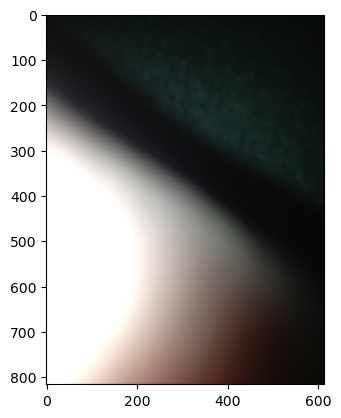

In [ ]:
#change the path to test image
# feedback('../Dataset/Vizwiz-Data/test/VizWiz_test_00000001.jpg', test_model, test_img)

# for Mobilenet
feedback('../Dataset/Vizwiz-Data/test/VizWiz_test_00000001.jpg', test_model, test_preprocessing)